In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#1.Setting a clean seaborn style for better aesthetics
sns.set_theme(style="whitegrid")

#Loading the exercise dataset
exercise_df = pd.read_csv("Exercise_Data.csv")

#Display the data so we can see what we have
print(exercise_df.head())
print(exercise_df.columns)

   id  1 min  15 min  30 min     diet  kind
0   1     85      85      88  low fat  rest
1   2     90      92      93  low fat  rest
2   3     97      97      94  low fat  rest
3   4     80      82      83  low fat  rest
4   5     91      92      91  low fat  rest
Index(['id', '1 min', '15 min', '30 min', 'diet', 'kind'], dtype='object')


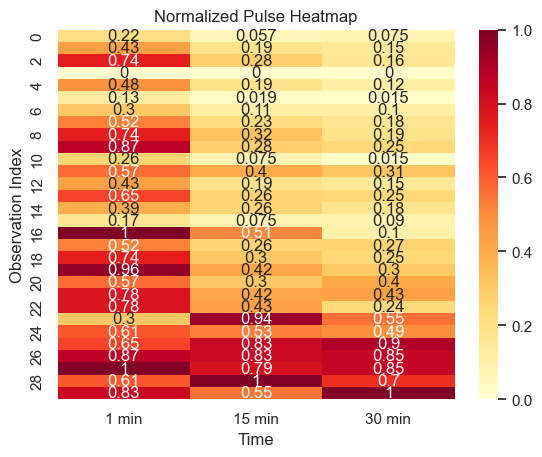

In [8]:
#Selecting only the pulse columns for the heatmap
pulse_data = exercise_df[["1 min", "15 min", "30 min"]]

#Normalizing the pulse values so the heatmap colors will be easier to compare
pulse_data = (pulse_data - pulse_data.min()) / (pulse_data.max() - pulse_data.min())

#Creating the heatmap
sns.heatmap(pulse_data, cmap="YlOrRd", annot=True)

plt.title("Normalized Pulse Heatmap")
plt.xlabel("Time")
plt.ylabel("Observation Index")

plt.show()

In [10]:
# Here converting the pulse columns into long-form format
# This is the format seaborn works best with for grouped categorical plots
exercise_long = exercise_df.melt( id_vars=["id", "diet", "kind"], value_vars=["1 min", "15 min", "30 min"], var_name="time", value_name="pulse"
)

print(exercise_long.head())

   id     diet  kind   time  pulse
0   1  low fat  rest  1 min     85
1   2  low fat  rest  1 min     90
2   3  low fat  rest  1 min     97
3   4  low fat  rest  1 min     80
4   5  low fat  rest  1 min     91


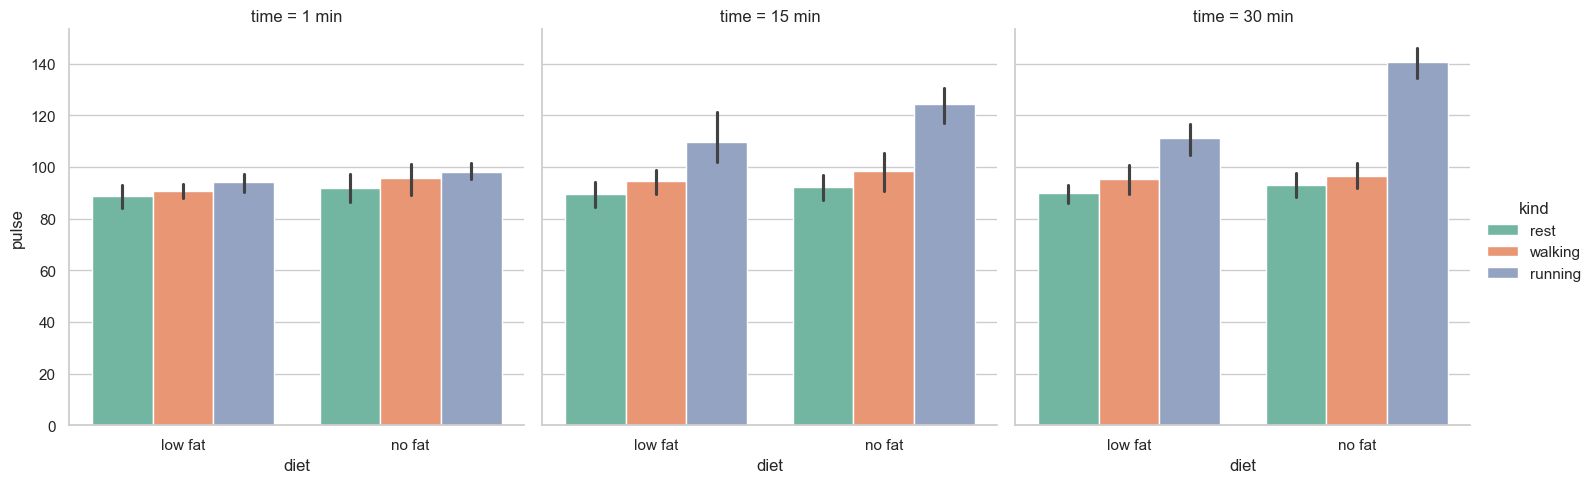

In [12]:
#This plot shows pulse values by diet, separated by time and exercise type
sns.catplot(data=exercise_long, x="diet", y="pulse", hue="kind", col="time", kind="bar", palette="Set2", height=5, aspect=1)

plt.show()

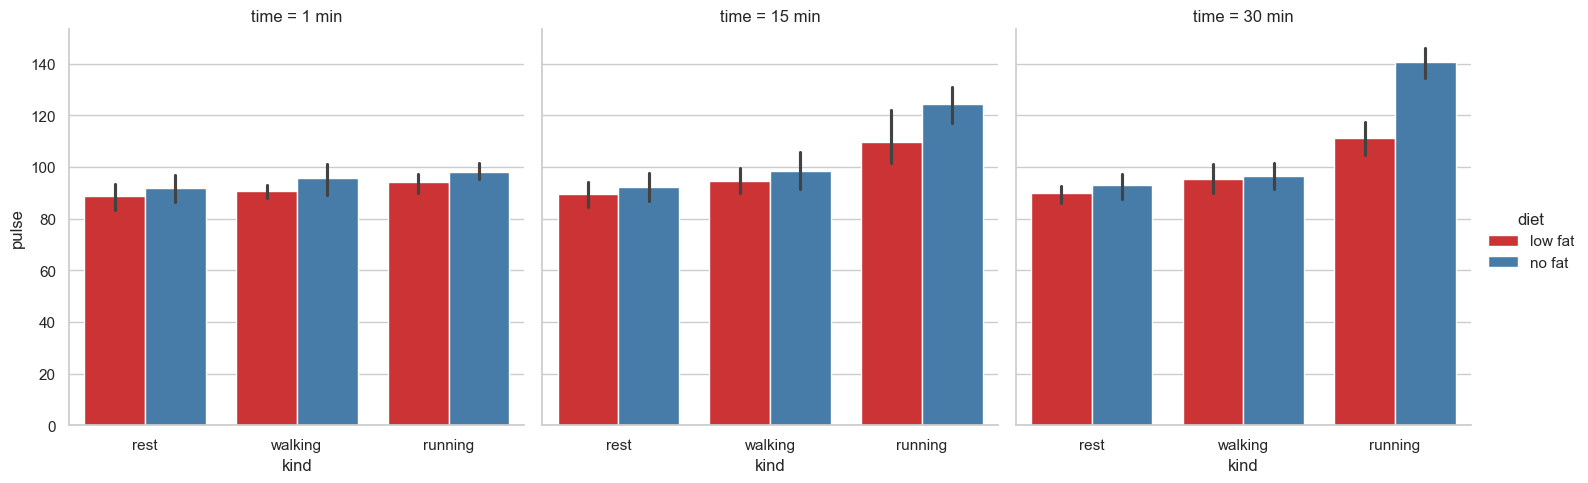

In [14]:
#This plot shows pulse values by the exercise type, separated by time and diet
sns.catplot(data=exercise_long, x="kind", y="pulse", hue="diet", col="time", kind="bar", palette="Set1", height=5, aspect=1)

plt.show()

In [ ]:
#From the exercise data, we can see that physical activity has a much bigger impact on heart rate than diet. When people are resting, their pulse is the lowest. As they move from walking to running, their pulse increases significantly.

#Diet (low fat vs. no fat) does have a small effect, but it is not as noticeable as the type of activity. For example, running always results in the highest pulse regardless of diet.

#This means that exercise intensity (how hard you move your body) is the main factor that changes heart rate, while diet plays a smaller role in the short term.

In [16]:
#2.Loading the built-in planets dataset from seaborn
planets = sns.load_dataset("planets")

# Inspecting the data so we know what we have [this is my own sanity check]
print(planets.head())
print(planets.columns)
print(planets.isna().sum())

            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1         269.300   7.10     77.40  2006
1  Radial Velocity       1         874.774   2.21     56.95  2008
2  Radial Velocity       1         763.000   2.60     19.84  2011
3  Radial Velocity       1         326.030  19.40    110.62  2007
4  Radial Velocity       1         516.220  10.50    119.47  2009
Index(['method', 'number', 'orbital_period', 'mass', 'distance', 'year'], dtype='object')
method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64


In [18]:
#Building a cleaned copy for easier plotting
planets_clean = planets.copy()


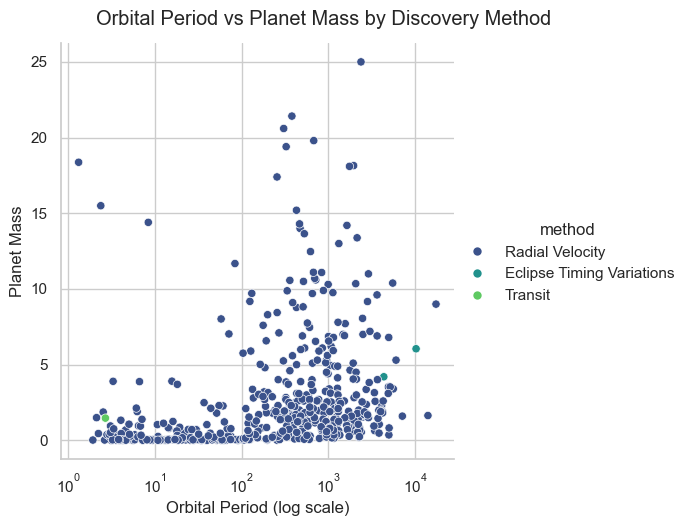

In [58]:
rel1_data = planets_clean.dropna(subset=["orbital_period", "mass", "number"]) #checking for missing rows for orbital_period, mass, and number.

g = sns.relplot( data=rel1_data, x="orbital_period", y="mass", hue="method", kind="scatter", palette="viridis")
    
g.set(xscale="log")
g.fig.suptitle("Orbital Period vs Planet Mass by Discovery Method", y=1.03)
g.set_axis_labels("Orbital Period (log scale)", "Planet Mass")

plt.show()

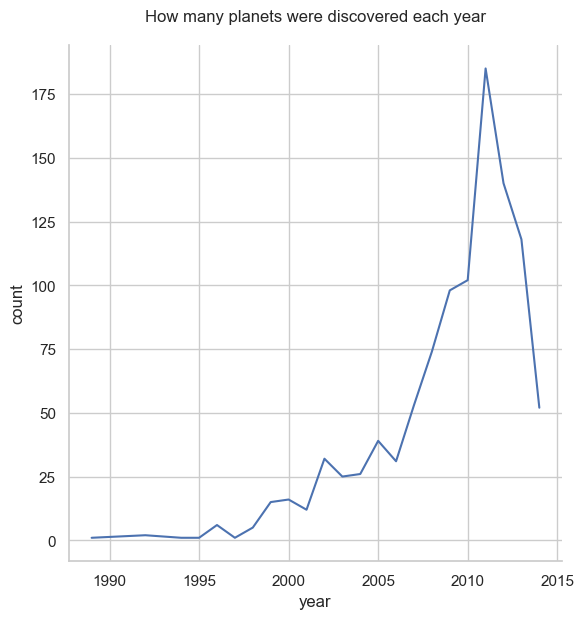

In [22]:
#Counting how many planets were discovered each year
discoveries_per_year = planets_clean.groupby("year").size().reset_index(name="count")

sns.relplot(data=discoveries_per_year, x="year", y="count", kind="line", height=6)
plt.title("How many planets were discovered each year", y=1.03)

plt.show()

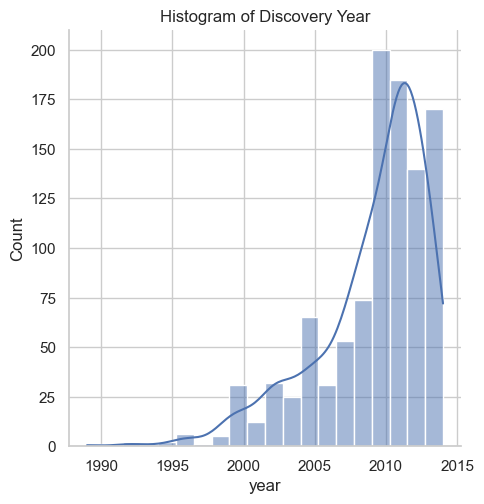

In [24]:
#histogram of the discovery years
dist1_data = planets_clean.dropna(subset=["year"]) #removing the rows where year is missing.

sns.displot(data=dist1_data, x="year", bins=20, kde=True,)

plt.title("Histogram of Discovery Year")
plt.show()


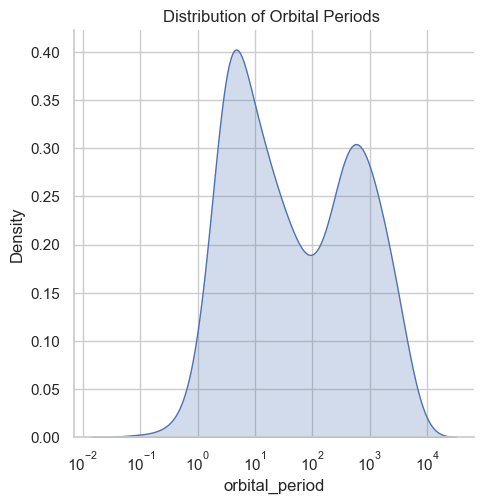

In [26]:
dist2_data = planets_clean.dropna(subset=["orbital_period"]) ##removing the rows where orbital_period is missing.

filtered = dist2_data[dist2_data["orbital_period"] < 5000]

sns.displot(data=filtered, x="orbital_period", kind="kde", fill=True, log_scale=True) #I used log_scale becuase the x axis values were very large

plt.title("Distribution of Orbital Periods ")
plt.show()

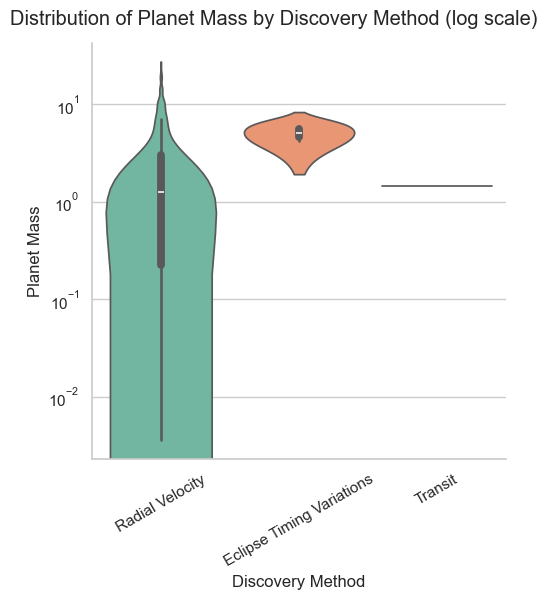

In [52]:
cat1_data = planets_top.dropna(subset=["method", "mass"])##removing the rows where method and mass are missing.

g = sns.catplot(data= cat1_data, x="method", y="mass", hue="method", kind="violin", palette="Set2", legend=False)

g.fig.suptitle("Distribution of Planet Mass by Discovery Method (log scale)", y=1.03)
g.set_axis_labels("Discovery Method", "Planet Mass")

plt.yscale("log") #limting the y axis from 0 to 10 to make the visulaization look better
plt.xticks(rotation=30)
plt.show()

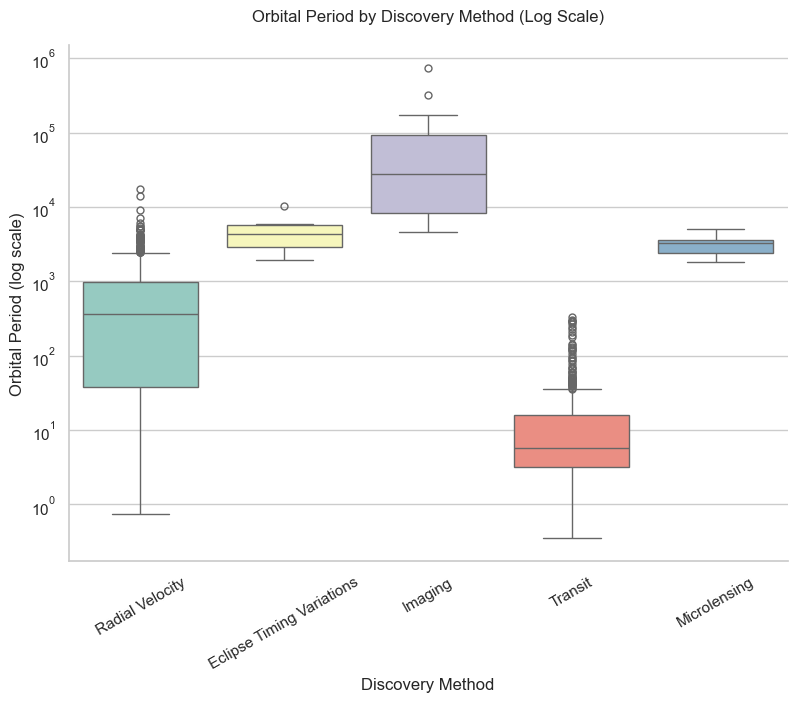

In [54]:
cat2_data = planets_top.dropna(subset=["method", "orbital_period"])

g = sns.catplot(data=cat2_data, x="method", y="orbital_period", hue="method", kind="box", palette="Set3", height=6, aspect=1.4, legend=False)


plt.yscale("log")
plt.xticks(rotation=30)

plt.title("Orbital Period by Discovery Method (Log Scale)", y=1.03)
g.set_axis_labels("Discovery Method", "Orbital Period (log scale)")

plt.show()

In [ ]:
#The grouped bar charts that show pulse values by exercise type and time best demonstrate the most notable pattern in the data. These graphs clearly illustrate how pulse increases from rest to walking to running across all time intervals.

#The separation into different time panels (1 min, 15 min, 30 min) makes it easy to see how pulse changes over time, while the color grouping highlights differences between diet types.

#This visualization is effective because it allows us to compare both exercise intensity and diet at the same time, making it clear that exercise type has a stronger impact on pulse than diet.